In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jillanisofttech/updated-resume-dataset/UpdatedResumeDataSet.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report , accuracy_score

In [3]:
df = pd.read_csv('/kaggle/input/datasets/jillanisofttech/updated-resume-dataset/UpdatedResumeDataSet.csv')

# Adil: "Let’s peek at the first few rows to get a sense of the data."
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [4]:
df.shape

(962, 2)

962 -- resume 

In [5]:
df['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

# Pipeline 

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64


/tmp/ipykernel_55/1689461609.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


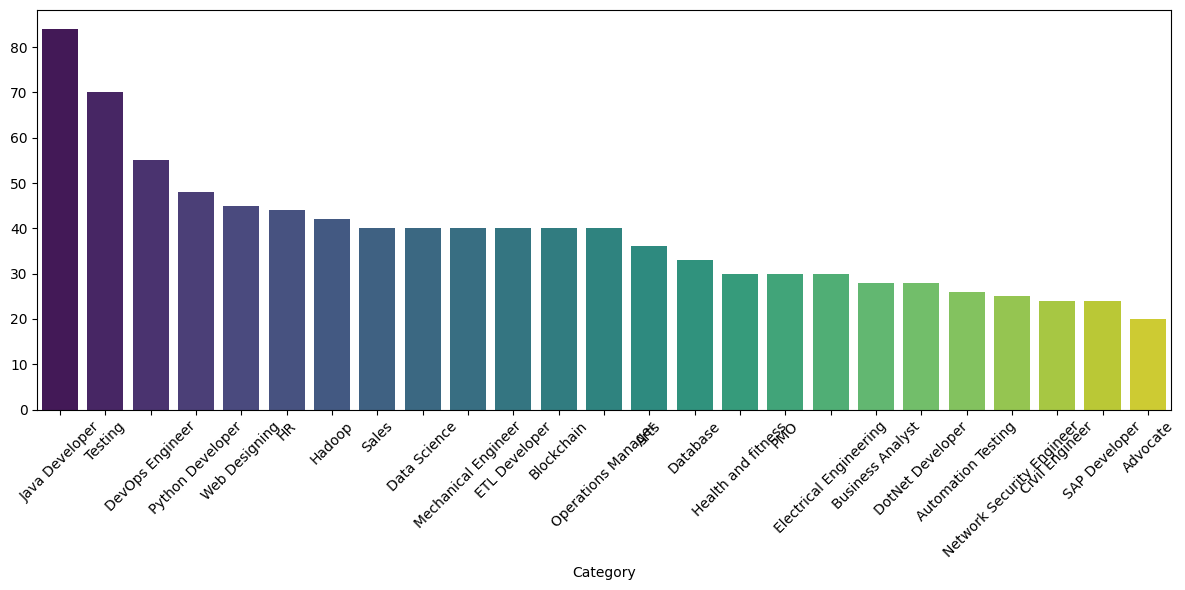

In [6]:
category_counts = df['Category'].value_counts()

# Display counts
print(category_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
plt.xticks(rotation=45)
plt.tight_layout()

In [7]:
## Total unique category 

unique_category = df['Category'].unique()

print(len(unique_category))
print(unique_category)

25
['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']


In [8]:
# explore resume 

print("Category:", df['Category'][0])
print("\nResume Preview:\n")
print(df['Resume'][0][:1000]) 

Category: Data Science

Resume Preview:

Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details 

Data Science Assurance Associate 

Data Science Assurance Associate - Ernst & Young LLP
Skill Details 
JAVASCRIPT- Exprience - 24 months
jQuery- Exprience - 24 months
Python- Exprience - 24 monthsCompany Details 
company - Ernst & Young LLP
description - Fraud In

### Clean Texts 

In [9]:
import re

def cleanResume(txt):
    # Remove URLs like http://something
    cleanText = re.sub(r'http\S+\s?', ' ', txt)
    
    # Remove Twitter RT (retweet) or cc if any
    cleanText = re.sub(r'RT|cc', ' ', cleanText)
    
    # Remove hashtags (#something)
    cleanText = re.sub(r'#\S+\s?', ' ', cleanText)
    
    # Remove mentions (@username)
    cleanText = re.sub(r'@\S+', ' ', cleanText)
    
    # Remove punctuation and special characters
    cleanText = re.sub(r'[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)
    
    # Remove non-ASCII characters (like emojis)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)
    
    # Replace multiple spaces with single space
    cleanText = re.sub(r'\s+', ' ', cleanText)
    
    # Strip leading/trailing spaces
    cleanText = cleanText.strip()
    
    return cleanText

# Test the function with an example
test_text = "my #### $ #  #noorsaeed webiste like is this http://heloword and access it @gmain.com"
print(cleanResume(test_text))

my webiste like is this and a ess it


<>:17: SyntaxWarning: invalid escape sequence '\]'
<>:17: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipykernel_55/3626407132.py:17: SyntaxWarning: invalid escape sequence '\]'
  cleanText = re.sub(r'[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)


In [10]:
df['Resume'] = df['Resume'].apply(cleanResume)

print(df['Resume'][0])

Skills Programming Languages Python pandas numpy scipy scikit learn matplotlib Sql Java JavaScript JQuery Machine learning Regression SVM Na ve Bayes KNN Random Forest Decision Trees Boosting techniques Cluster Analysis Word Embedding Sentiment Analysis Natural Language processing Dimensionality reduction Topic Modelling LDA NMF PCA Neural Nets Database Visualizations Mysql SqlServer Cassandra Hbase ElasticSearch D3 js DC js Plotly kibana matplotlib ggplot Tableau Others Regular Expression HTML CSS Angular 6 Logstash Kafka Python Flask Git Docker computer vision Open CV and understanding of Deep learning Education Details Data Science Assurance Associate Data Science Assurance Associate Ernst Young LLP Skill Details JAVASCRIPT Exprience 24 months jQuery Exprience 24 months Python Exprience 24 monthsCompany Details company Ernst Young LLP description Fraud Investigations and Dispute Services Assurance TECHNOLOGY ASSISTED REVIEW TAR Technology Assisted Review assists in a elerating the r

## Vectorization 

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer( max_features=500)

X = tfidf.fit_transform(df['Resume'])
y = df['Category']

In [12]:
X.shape

(962, 500)

In [13]:
type(X)

scipy.sparse._csr.csr_matrix

## Handle Class Imbalance 

In [14]:
smote = SMOTE()

X_res , y_res = smote.fit_resample(X,y)

In [15]:
y_res.value_counts()

Category
Data Science                 84
HR                           84
Advocate                     84
Arts                         84
Web Designing                84
Mechanical Engineer          84
Sales                        84
Health and fitness           84
Civil Engineer               84
Java Developer               84
Business Analyst             84
SAP Developer                84
Automation Testing           84
Electrical Engineering       84
Operations Manager           84
Python Developer             84
DevOps Engineer              84
Network Security Engineer    84
PMO                          84
Database                     84
Hadoop                       84
ETL Developer                84
DotNet Developer             84
Blockchain                   84
Testing                      84
Name: count, dtype: int64

## Encoding target col 

In [16]:
le = LabelEncoder()

y_res = le.fit_transform(y_res)

In [17]:
y_res

array([ 6,  6,  6, ..., 24, 24, 24])

## Modelling 

In [18]:
X_train, X_test , y_train, y_test = train_test_split( X_res, y_res, test_size=0.2, random_state=42)

In [19]:
X_train.shape

(1680, 500)

In [20]:
X_test.shape

(420, 500)

## Logistic Regression 

In [21]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

LogisticRegression()

In [22]:
y_pred_lr = lr.predict(X_test)

print(accuracy_score(y_pred_lr, y_test))
print(classification_report(y_pred_lr, y_test))

0.9952380952380953
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        20
           2       1.00      0.94      0.97        16
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        19
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        12
           7       1.00      1.00      1.00        24
           8       0.88      1.00      0.94        15
           9       1.00      0.95      0.97        20
          10       1.00      1.00      1.00        19
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        21
          13       1.00      1.00      1.00        13
          14       1.00      1.00      1.00        16
          15       1.00      1.00      1.00        16
          16       1.00      1.00      1.00        19
        

<Axes: >

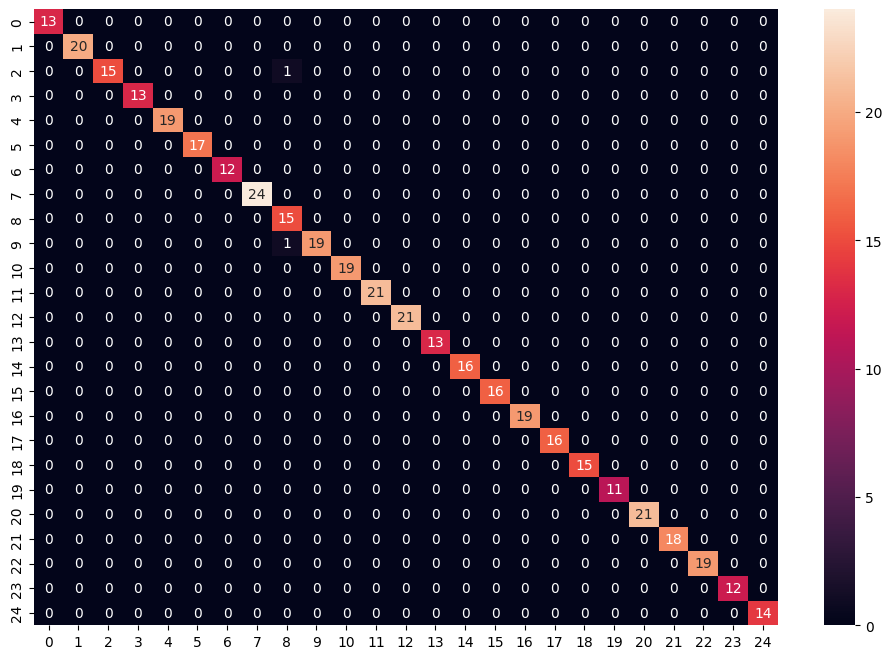

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap( confusion_matrix(y_pred_lr, y_test), annot=True)

## RandomForestClassifier

In [24]:
rfc = RandomForestClassifier()

rfc.fit(X_train, y_train)

RandomForestClassifier()

In [25]:
y_pred_rfc = rfc.predict(X_test)

print(accuracy_score(y_pred_rfc, y_test))
print(classification_report(y_pred_rfc, y_test))

0.9952380952380953
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        20
           2       1.00      0.94      0.97        16
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        19
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        12
           7       1.00      1.00      1.00        24
           8       0.88      1.00      0.94        15
           9       1.00      0.95      0.97        20
          10       1.00      1.00      1.00        19
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        21
          13       1.00      1.00      1.00        13
          14       1.00      1.00      1.00        16
          15       1.00      1.00      1.00        16
          16       1.00      1.00      1.00        19
        

## SOAT - ( BERT + LogisticRegression ) 

In [26]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 12.3 MB/s eta 0:00:0000:01
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.2.3
    Uninstalling sentence-transformers-5.2.3:
      Successfully uninstalled sentence-transformers-5.2.3


In [27]:
from sentence_transformers import SentenceTransformer

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [28]:
# Convert resumes to embeddings
X = model.encode(df['Resume'].tolist())

y = df['Category']

In [29]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train classifier
clf = LogisticRegression(class_weight='balanced')
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [30]:
y_pred_clf = clf.predict(X_test)

print(accuracy_score(y_pred_clf, y_test))
print(classification_report(y_pred_clf, y_test))

0.9844559585492227
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         8
                     Arts       1.00      1.00      1.00         6
       Automation Testing       1.00      1.00      1.00         5
               Blockchain       1.00      1.00      1.00        10
         Business Analyst       0.83      1.00      0.91         5
           Civil Engineer       1.00      1.00      1.00         7
             Data Science       1.00      1.00      1.00         9
                 Database       1.00      0.86      0.92         7
          DevOps Engineer       1.00      1.00      1.00         7
         DotNet Developer       1.00      1.00      1.00         6
            ETL Developer       1.00      1.00      1.00         9
   Electrical Engineering       1.00      1.00      1.00         4
                       HR       0.80      1.00      0.89         8
                   Hadoop       1.00      